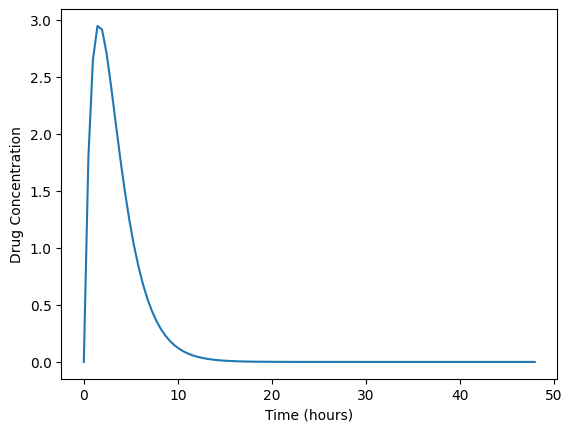

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

def pk_model(t, y, dose, ka, Vd, CL):
    """One-compartment PK model"""
    amount = y[0]
    d_amount_dt = -ka * amount + (dose / Vd) * np.exp(-ka * t) - (CL / Vd) * amount
    return d_amount_dt

# Parameters
dose = 100  # mg
ka = 0.5   # 1/hour
Vd = 20    # L
CL = 5     # L/hour

# Simulation
time_points = np.linspace(0, 48, 100)  # 48 hours
initial_condition = 0  # No drug initially
result = solve_ivp(pk_model, [0, 48], [initial_condition], args=(dose, ka, Vd, CL), t_eval=time_points)

# Plot
import matplotlib.pyplot as plt
plt.plot(result.t, result.y[0])
plt.xlabel('Time (hours)')
plt.ylabel('Drug Concentration')
plt.show()
